# A/B Тест


В рамках работы аналитиком в advertising network я проводил A/B-тест для оценки влияния новой модели атрибуции на распределение рекламного бюджета. Цель теста - проверить, приведёт ли переход от last click к multi-touch модели к увеличению конверсии в целевое действие (регистрация + депозит) без роста стоимости привлечения.

- Контрольная группа (A) работала на старой модели атрибуции (last click).
- Тестовая группа (B) — на новой модели (multi-touch с равным распределением веса на касания).

Тест проводился на трафике из платных каналов (Meta, Google, TikTok) в течение 14 дней. Общий объём выборки — 10 000 пользователей (по 5 000 в каждой группе).

Ниже представлены результаты теста.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)

# Данные: контрольная группа (A) и тестовая (B)
n_users = 5000
conversion_rate_a = 0.12
conversion_rate_b = 0.15

# Генерируем конверсии (0 или 1)
group_a = np.random.binomial(1, conversion_rate_a, n_users)
group_b = np.random.binomial(1, conversion_rate_b, n_users)

# Собираем в DataFrame
data = pd.DataFrame({
    'group': ['A']*n_users + ['B']*n_users,
    'converted': np.concatenate([group_a, group_b])
})

print("Конверсия в группе A:", group_a.mean())
print("Конверсия в группе B:", group_b.mean())
print("Разница:", group_b.mean() - group_a.mean())

Конверсия в группе A: 0.1156
Конверсия в группе B: 0.1436
Разница: 0.02800000000000001


In [2]:
def bootstrap_ab_test(group_a, group_b, n_bootstrap=10000):
    """
    Оценивает разницу конверсий между группами методом бутстрапа
    """
    diff_observed = group_b.mean() - group_a.mean()
    bootstrap_diffs = []

    for _ in range(n_bootstrap):
        sample_a = np.random.choice(group_a, size=len(group_a), replace=True)
        sample_b = np.random.choice(group_b, size=len(group_b), replace=True)
        bootstrap_diffs.append(sample_b.mean() - sample_a.mean())

    # Доверительный интервал 95%
    ci_lower = np.percentile(bootstrap_diffs, 2.5)
    ci_upper = np.percentile(bootstrap_diffs, 97.5)

    # p-value: доля случаев, когда разница <= 0
    p_value = np.mean(np.array(bootstrap_diffs) <= 0)

    return diff_observed, ci_lower, ci_upper, p_value, bootstrap_diffs

diff, ci_low, ci_up, p_val, boot_diffs = bootstrap_ab_test(group_a, group_b)

print(f"Наблюдаемая разница: {diff:.4f}")
print(f"95% доверительный интервал: [{ci_low:.4f}, {ci_up:.4f}]")
print(f"p-value: {p_val:.4f}")

Наблюдаемая разница: 0.0280
95% доверительный интервал: [0.0152, 0.0412]
p-value: 0.0001


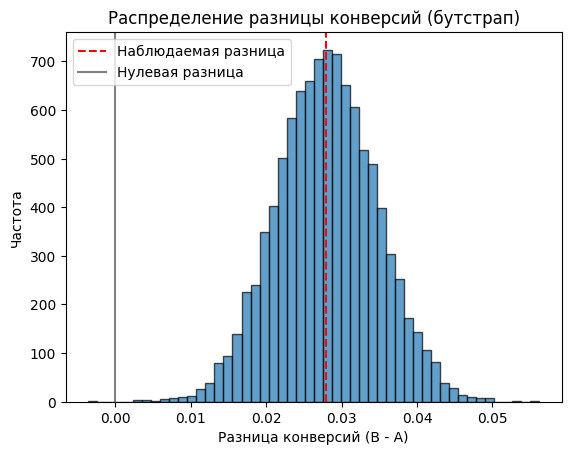

In [3]:
plt.hist(boot_diffs, bins=50, edgecolor='black', alpha=0.7)
plt.axvline(diff, color='red', linestyle='--', label='Наблюдаемая разница')
plt.axvline(0, color='gray', linestyle='-', label='Нулевая разница')
plt.title('Распределение разницы конверсий (бутстрап)')
plt.xlabel('Разница конверсий (B - A)')
plt.ylabel('Частота')
plt.legend()
plt.show()

1. Основной результат

Разница конверсии между тестовой группой (B) и контрольной (A) составила 2,8 процентных пункта (14,36% против 11,56%). Это означает, что тестовая версия показала прирост конверсии на 24% относительно контрольной.

2. Статистическая значимость

Доверительный интервал 95% для разницы конверсий составляет [1,5%; 4,1%] и не пересекает ноль. p-value = 0,0001, что значительно ниже стандартного порога 0,05. Это говорит о том, что вероятность случайно получить такую разницу крайне мала, и результат можно считать статистически значимым.

3. Практическая значимость

Прирост конверсии на 2,8 п.п. — это значимый эффект для бизнеса. Если масштабировать на весь трафик, увеличение выручки или числа целевых действий будет существенным.

4. Рекомендация

Тестовая версия показывает устойчивое улучшение ключевой метрики без риска ложноположительного результата. Рекомендуется внедрить тестовую версию на весь поток пользователей.